In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure that visualizations display inline directly below the code cells
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define column names based on the dataset structure
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']

# Load the training and validation datasets
train_df = pd.read_csv('twitter_training.csv', header=None, names=column_names)
validation_df = pd.read_csv('twitter_validation.csv', header=None, names=column_names)

# View the first 5 rows of the training dataset
print(f"Training Dataset Shape: {train_df.shape}")
print(f"Validation Dataset Shape: {validation_df.shape}")
train_df.head()

Training Dataset Shape: (74682, 4)
Validation Dataset Shape: (1000, 4)


,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
# Check for missing values in both datasets
print("Missing values in Training Data:")
print(train_df.isnull().sum())

# Drop rows where the tweet content is missing to avoid errors during analysis
train_df.dropna(subset=['Tweet_Content'], inplace=True)
validation_df.dropna(subset=['Tweet_Content'], inplace=True)

# Verify that missing values have been handled
print("\nMissing values after cleaning:")
print(train_df.isnull().sum())

Missing values in Training Data:
Tweet_ID           0
Entity             0
Sentiment          0
Tweet_Content    686
dtype: int64

Missing values after cleaning:
Tweet_ID         0
Entity           0
Sentiment        0
Tweet_Content    0
dtype: int64


C:\Users\SHIVA\AppData\Local\Temp\ipykernel_15912\537757024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


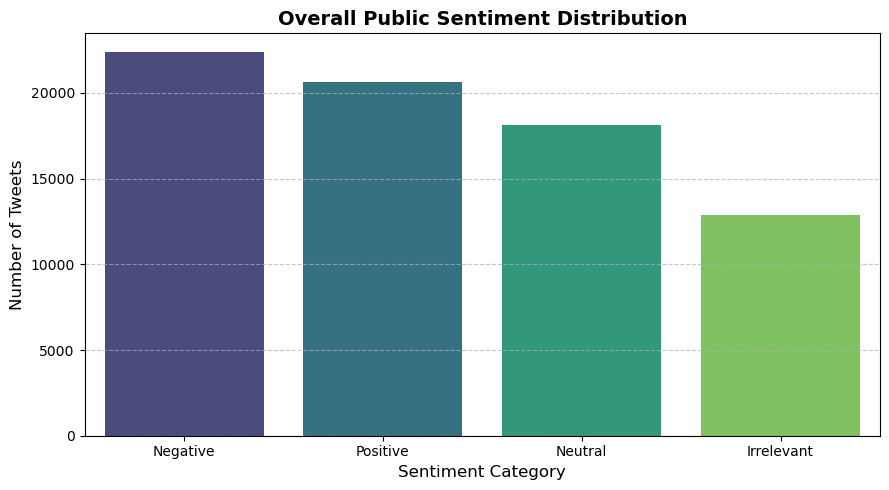

In [4]:
# Plot overall sentiment distribution
plt.figure(figsize=(9, 5))
sns.countplot(
    x='Sentiment', 
    data=train_df, 
    order=train_df['Sentiment'].value_counts().index, 
    palette='viridis'
)

plt.title('Overall Public Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

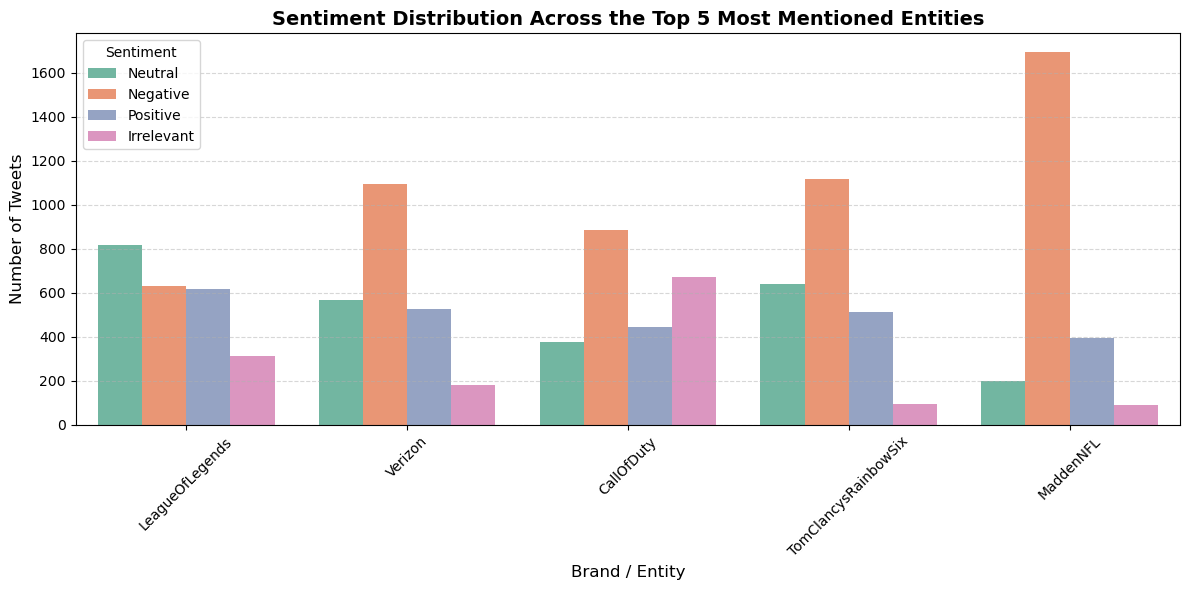

In [5]:
# Find the top 5 most mentioned entities
top_entities = train_df['Entity'].value_counts().head(5).index
df_top_entities = train_df[train_df['Entity'].isin(top_entities)]

# Plot sentiment breakdown per entity
plt.figure(figsize=(12, 6))
sns.countplot(
    x='Entity', 
    hue='Sentiment', 
    data=df_top_entities, 
    palette='Set2'
)

plt.title('Sentiment Distribution Across the Top 5 Most Mentioned Entities', fontsize=14, fontweight='bold')
plt.xlabel('Brand / Entity', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\SHIVA\AppData\Local\Temp\ipykernel_15912\3360617944.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


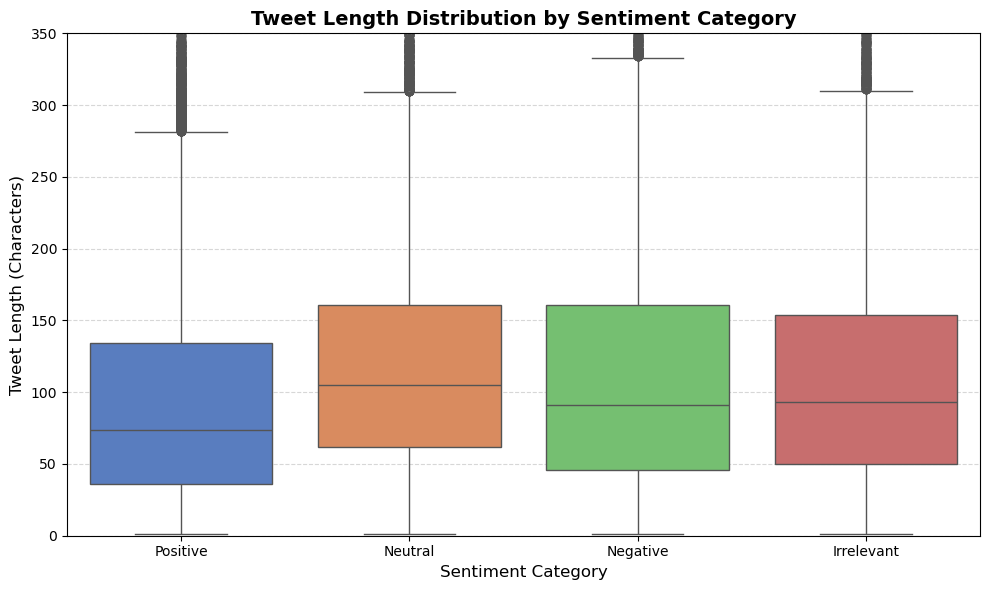

In [6]:
# Calculate character length for each tweet
train_df['Tweet_Length'] = train_df['Tweet_Content'].apply(lambda x: len(str(x)))

# Plot tweet length distribution per sentiment category using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Sentiment', 
    y='Tweet_Length', 
    data=train_df, 
    palette='muted'
)

plt.title('Tweet Length Distribution by Sentiment Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Tweet Length (Characters)', fontsize=12)

# Limit the y-axis to focus on the core box distributions and minimize outlier clutter
plt.ylim(0, 350)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

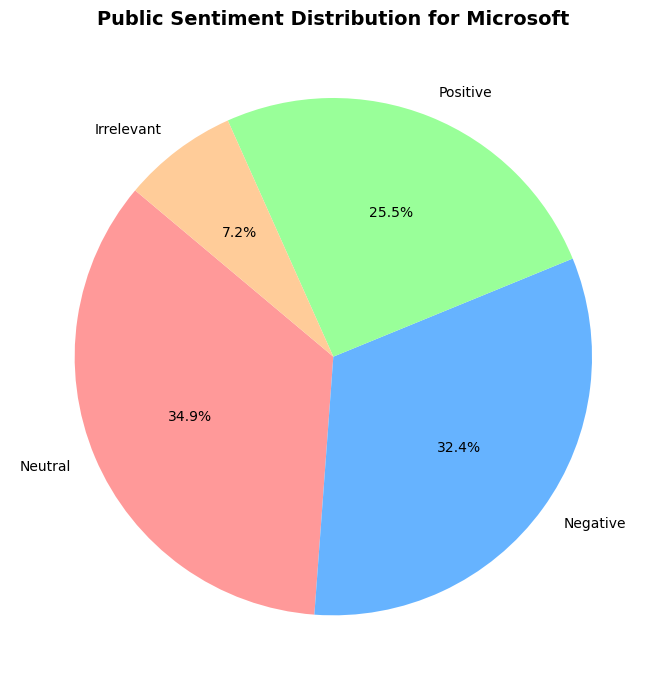

In [7]:
# Filter the data for a specific brand
brand_name = 'Microsoft'
brand_df = train_df[train_df['Entity'] == brand_name]

# Calculate sentiment percentages
sentiment_counts = brand_df['Sentiment'].value_counts()

# Plot a pie chart to visualize sentiment share for the brand
plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)

plt.title(f'Public Sentiment Distribution for {brand_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()